In [1]:
from mpi4py import MPI
import numpy as np
import ufl
from dolfinx import mesh, fem, default_scalar_type
from dolfinx.fem.petsc import LinearProblem
import basix.ufl
import matplotlib.pyplot as plt

In [3]:
N = 32
domain = mesh.create_rectangle(
    MPI.COMM_WORLD,
    [np.array([0.0, 0.0]), np.array([np.pi, np.pi])],
    [N, N], mesh.CellType.triangle,
)

#Define the constant
d_const = 1.0

In [4]:
# Mixed Space P2xP2

P2 = basix.ufl.element("Lagrange", domain.basix_cell(), 2)
ME = fem.functionspace(domain, basix.ufl.mixed_element([P2, P2]))

(u, w) = ufl.TrialFunction(ME)
(v, q) = ufl.TestFunction(ME)

In [5]:
#Variational formula

x = ufl.SpatialCoordinate(domain)
u_exact = ufl.sin(x[0]) * ufl.sin(x[1])
f = 4 * d_const * u_exact

a = (ufl.inner(ufl.grad(u), ufl.grad(v)) - ufl.inner(w, v)) * ufl.dx \
    + ufl.inner(ufl.grad(w), ufl.grad(q)) * ufl.dx
L = ufl.inner(f / d_const, q) * ufl.dx

In [6]:
# Boundary facets
tdim = domain.topology.dim
fdim = tdim - 1

domain.topology.create_connectivity(fdim, tdim)
facets = mesh.exterior_facet_indices(domain.topology)

# Collapsed spaces
Vu, _ = ME.sub(0).collapse()
Vw, _ = ME.sub(1).collapse()

# u boundary DOFs
dofs_u = fem.locate_dofs_topological(
    (ME.sub(0), Vu),
    fdim,
    facets
)

# w boundary DOFs
dofs_w = fem.locate_dofs_topological(
    (ME.sub(1), Vw),
    fdim,
    facets
)

# Boundary values
u_bc = fem.Function(Vu)
u_bc.x.array[:] = 0.0

w_bc = fem.Function(Vw)
w_bc.x.array[:] = 0.0

# Dirichlet BCs
bc_u = fem.dirichletbc(
    u_bc,
    dofs_u,
    ME.sub(0)
)

bc_w = fem.dirichletbc(
    w_bc,
    dofs_w,
    ME.sub(1)
)

bcs = [bc_u, bc_w]

In [7]:
# Solve the problem

problem = fem.petsc.LinearProblem(
    a,
    L,
    bcs=bcs,
    petsc_options_prefix="biharmonic_",
    petsc_options={
        "ksp_type": "preonly",
        "pc_type": "lu"
    }
)

sol = problem.solve()

u_h, w_h = sol.split()

In [8]:
u_h_full = sol.sub(0).collapse()
erro_form = fem.form(ufl.inner(u_h_full - u_exact, u_h_full - u_exact) * ufl.dx)
erro_L2 = np.sqrt(domain.comm.allreduce(fem.assemble_scalar(erro_form), op=MPI.SUM))
print(f"Erro L2:", erro_L2)

Erro L2: 2.713967364440914e-05


In [9]:
ref = [8, 16, 32, 64, 128]

erros_u = []
erros_w = []

for n in ref:
    N = n
    domain = mesh.create_rectangle(
        MPI.COMM_WORLD,
        [np.array([0.0, 0.0]), np.array([np.pi, np.pi])],
        [N, N], mesh.CellType.triangle,
    )

    #Define the constant
    d_const = 1.0
    # Mixed Space P2xP2

    P2 = basix.ufl.element("Lagrange", domain.basix_cell(), 2)
    ME = fem.functionspace(domain, basix.ufl.mixed_element([P2, P2]))

    (u, w) = ufl.TrialFunction(ME)
    (v, q) = ufl.TestFunction(ME)
    #Variational formula

    x = ufl.SpatialCoordinate(domain)
    u_exact = ufl.sin(x[0]) * ufl.sin(x[1])
    f = 4 * d_const * u_exact

    a = (ufl.inner(ufl.grad(u), ufl.grad(v)) - ufl.inner(w, v)) * ufl.dx \
        + ufl.inner(ufl.grad(w), ufl.grad(q)) * ufl.dx
    L = ufl.inner(f / d_const, q) * ufl.dx
    # Boundary facets
    tdim = domain.topology.dim
    fdim = tdim - 1

    domain.topology.create_connectivity(fdim, tdim)
    facets = mesh.exterior_facet_indices(domain.topology)

    # Collapsed spaces
    Vu, _ = ME.sub(0).collapse()
    Vw, _ = ME.sub(1).collapse()

    # u boundary DOFs
    dofs_u = fem.locate_dofs_topological(
        (ME.sub(0), Vu),
        fdim,
        facets
    )

    # w boundary DOFs
    dofs_w = fem.locate_dofs_topological(
        (ME.sub(1), Vw),
        fdim,
        facets
    )

    # Boundary values
    u_bc = fem.Function(Vu)
    u_bc.x.array[:] = 0.0

    w_bc = fem.Function(Vw)
    w_bc.x.array[:] = 0.0

    # Dirichlet BCs
    bc_u = fem.dirichletbc(
        u_bc,
        dofs_u,
        ME.sub(0)
    )

    bc_w = fem.dirichletbc(
        w_bc,
        dofs_w,
        ME.sub(1)
    )

    bcs = [bc_u, bc_w]
    # Solve the problem

    problem = fem.petsc.LinearProblem(
        a,
        L,
        bcs=bcs,
        petsc_options_prefix="biharmonic_",
        petsc_options={
            "ksp_type": "preonly",
            "pc_type": "lu"
        }
    )

    sol = problem.solve()

    u_h, w_h = sol.split()

    w_exact = 2 * u_exact


    u_h_full = sol.sub(0).collapse()
    erro_form_u = fem.form(ufl.inner(u_h_full - u_exact, u_h_full - u_exact) * ufl.dx)
    erro_L2_u = np.sqrt(domain.comm.allreduce(fem.assemble_scalar(erro_form_u), op=MPI.SUM))
    #print(f"Erro L2 de u:", erro_L2_u)


    w_h_full = sol.sub(1).collapse()
    erro_form_w = fem.form(ufl.inner(w_h_full - w_exact, w_h_full - w_exact) * ufl.dx)
    erro_L2_w = np.sqrt(domain.comm.allreduce(fem.assemble_scalar(erro_form_w), op=MPI.SUM))
    #print(f"Erro L2 de w:", erro_L2_w)

    erros_u.append(erro_L2_u)
    erros_w.append(erro_L2_w)



print("="*10)
print("Erro de u")
for er_u in erros_u:    
    print(f"Erro L2 de u:", er_u)
print("="*10)

print("="*10)
print("Erro de w")
for er_w in erros_w:    
    print(f"Erro L2 de w:", er_w)
print("="*10)

Erro de u
Erro L2 de u: 0.0018346366619047436
Erro L2 de u: 0.00021972992043841908
Erro L2 de u: 2.713967364440914e-05
Erro L2 de u: 3.3820779989889773e-06
Erro L2 de u: 4.2243489784320365e-07
Erro de w
Erro L2 de w: 0.0034435744849749027
Erro L2 de w: 0.0004319008831151742
Erro L2 de w: 5.4038756824135825e-05
Erro L2 de w: 6.756602432253719e-06
Erro L2 de w: 8.446335263684502e-07


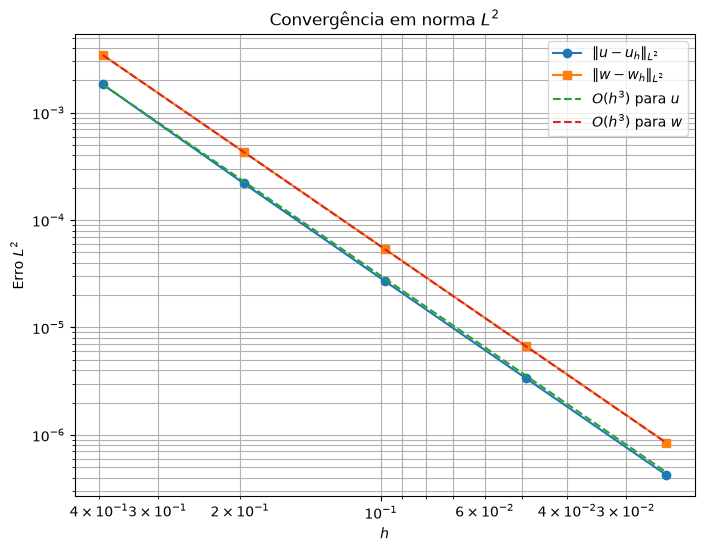

In [10]:
h = np.array([np.pi / N for N in ref])

plt.figure(figsize=(8, 6))

# Erros
plt.loglog(h, erros_u, "o-", label=r"$\|u-u_h\|_{L^2}$")
plt.loglog(h, erros_w, "s-", label=r"$\|w-w_h\|_{L^2}$")

# Referência O(h^3)
C_u = erros_u[0] / h[0]**3
C_w = erros_w[0] / h[0]**3

plt.loglog(
    h,
    C_u * h**3,
    "--",
    label=r"$O(h^3)$ para $u$"
)

plt.loglog(
    h,
    C_w * h**3,
    "--",
    label=r"$O(h^3)$ para $w$"
)

plt.gca().invert_xaxis()

plt.xlabel(r"$h$")
plt.ylabel(r"Erro $L^2$")
plt.title(r"Convergência em norma $L^2$")
plt.legend()
plt.grid(True, which="both")

plt.show()

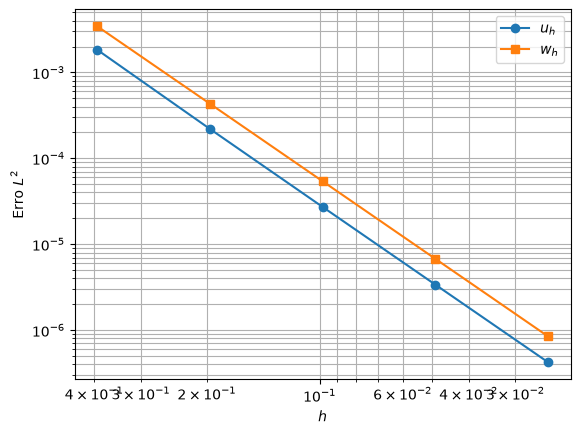

In [11]:
plt.loglog(h, erros_u, "o-", label=r"$u_h$")
plt.loglog(h, erros_w, "s-", label=r"$w_h$")

plt.gca().invert_xaxis()

plt.xlabel(r"$h$")
plt.ylabel(r"Erro $L^2$")
plt.legend()
plt.grid(True, which="both")

plt.show()

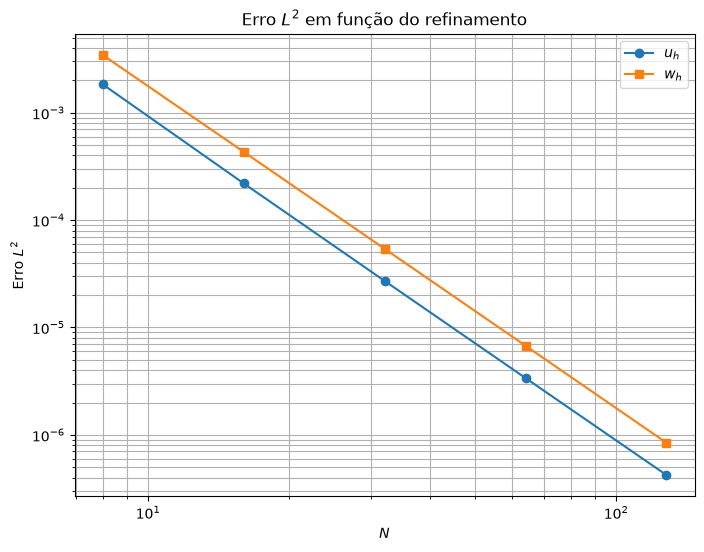

In [12]:
plt.figure(figsize=(8, 6))

plt.loglog(ref, erros_u, "o-", label=r"$u_h$")
plt.loglog(ref, erros_w, "s-", label=r"$w_h$")

plt.xlabel(r"$N$")
plt.ylabel(r"Erro $L^2$")
plt.title("Erro $L^2$ em função do refinamento")
plt.legend()
plt.grid(True, which="both")

plt.show()

In [13]:
def calcular_eoc(erros, ref):
    taxas = []
    for i in range(len(erros) - 1):
        r = np.log(erros[i] / erros[i+1]) / np.log(ref[i+1] / ref[i])
        taxas.append(r)
    return taxas

taxas_u = calcular_eoc(erros_u, ref)
taxas_w = calcular_eoc(erros_w, ref)

print("=" * 30)
print(f"{'N':<8}{'Erro L2 (u)':<18}{'EOC (u)':<10}{'Erro L2 (w)':<18}{'EOC (w)':<10}")
print("=" * 30)

for i in range(len(ref)):
    eoc_u_str = f"{taxas_u[i-1]:.2f}" if i > 0 else "-"
    eoc_w_str = f"{taxas_w[i-1]:.2f}" if i > 0 else "-"
    print(f"{ref[i]:<8}{erros_u[i]:<18.4e}{eoc_u_str:<10}{erros_w[i]:<18.4e}{eoc_w_str:<10}")

print("=" * 30)

N       Erro L2 (u)       EOC (u)   Erro L2 (w)       EOC (w)   
8       1.8346e-03        -         3.4436e-03        -         
16      2.1973e-04        3.06      4.3190e-04        3.00      
32      2.7140e-05        3.02      5.4039e-05        3.00      
64      3.3821e-06        3.00      6.7566e-06        3.00      
128     4.2243e-07        3.00      8.4463e-07        3.00      


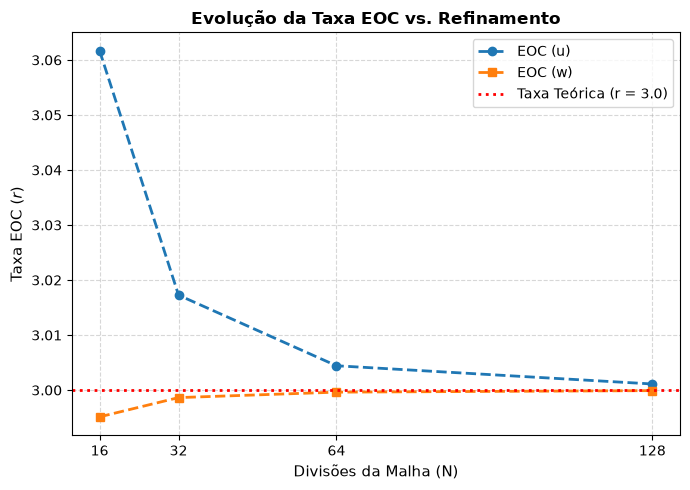

In [22]:
# Cálculo da EOC
eoc_u = [np.log(erros_u[i]/erros_u[i+1]) / np.log(ref[i+1]/ref[i]) for i in range(len(erros_u)-1)]
eoc_w = [np.log(erros_w[i]/erros_w[i+1]) / np.log(ref[i+1]/ref[i]) for i in range(len(erros_w)-1)]

# Configuração da figura individual
fig, ax = plt.subplots(figsize=(7, 5))

mid_N = ref[1:]
ax.plot(mid_N, eoc_u, 'o--', color='#1f77b4', linewidth=2, label='EOC (u)')
ax.plot(mid_N, eoc_w, 's--', color='#ff7f0e', linewidth=2, label='EOC (w)')
ax.axhline(y=3.0, color='r', linestyle=':', linewidth=2, label='Taxa Teórica (r = 3.0)')

ax.set_xlabel('Divisões da Malha (N)', fontsize=11)
ax.set_ylabel('Taxa EOC ($r$)', fontsize=11)
ax.set_title('Evolução da Taxa EOC vs. Refinamento', fontsize=12, fontweight='bold')
ax.set_xticks(mid_N)
ax.grid(True, ls="--", alpha=0.5)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

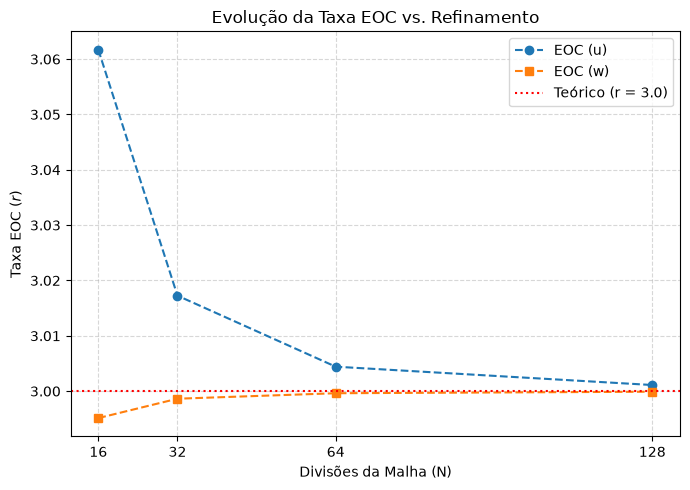

In [23]:
# Converte para arrays do NumPy para vetorizar o cálculo
u, w, N = np.array(erros_u), np.array(erros_w), np.array(ref)

# Cálculo da EOC sem loops
eoc_u = np.log(u[:-1] / u[1:]) / np.log(N[1:] / N[:-1])
eoc_w = np.log(w[:-1] / w[1:]) / np.log(N[1:] / N[:-1])

# Gráfico
plt.figure(figsize=(7, 5))
plt.plot(N[1:], eoc_u, 'o--', label='EOC (u)')
plt.plot(N[1:], eoc_w, 's--', label='EOC (w)')
plt.axhline(3.0, color='r', linestyle=':', label='Teórico (r = 3.0)')

plt.xlabel('Divisões da Malha (N)')
plt.ylabel('Taxa EOC ($r$)')
plt.title('Evolução da Taxa EOC vs. Refinamento')
plt.xticks(N[1:])
plt.grid(True, ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()